# TASS 2018 — Bag-of-Words + rasgos léxicos (`TextProcessing` + `FeatureExtraction`)

**Curso de Procesamiento de Lenguaje Natural ** · Unidad 3 — Text Classification
**Base:** `tass_bow_softmax_workshop.ipynb` (BoW + Softmax). Este notebook conserva su clasificador (`LogisticRegression`, `C=10`), sus n-gramas (1–3), el `RandomOverSampler` y la validación de 10 particiones `ShuffleSplit` (75/25), y agrega la estrategia nueva usando las clases de apoyo del curso. Además incorpora un **SVM lineal con `class_weight="balanced"`** como segunda forma de tratar el desbalance, para compararlo con el sobremuestreo.
**Referencia:** Jurafsky & Martin, *Speech and Language Processing* (borrador 2026), cap. 4 y Apéndice B.

## Estrategias comparadas

| Id | Preprocesamiento | Representación | Qué aísla |
|---|---|---|---|
| **E0** | `content.lower()` (el *fallback* del workshop) | BoW 1–3 gramas | Línea base |
| **E1** | `TextProcessing.transformer()` | BoW 1–3 gramas | Efecto del preprocesamiento |
| **E2 (nueva)** | `TextProcessing.transformer()` + variante con acentos | BoW 1–3 gramas **+ 29 rasgos léxicos** (`FeatureExtraction`) | Efecto de los rasgos diseñados manualmente |

**Pregunta de investigación.** ¿Añadir rasgos léxicos (pronombres, adverbios, adjetivos, etiquetas de Twitter, longitud de palabras) mejora la clasificación de polaridad respecto a BoW solo, y en qué clases?

## Dos protocolos de validación

El workshop aplica `RandomOverSampler` a **todo** *train* y luego hace la validación cruzada sobre los datos ya sobremuestreados. Como el sobremuestreo duplica tweets, copias del mismo tweet quedan a la vez en el pliegue de entrenamiento y en el de validación: el modelo se evalúa con tweets que ya vio. Con trigramas y `C=10` el modelo puede memorizarlos y la métrica sube artificialmente.

Por eso cada estrategia se evalúa con:

- **Protocolo W (workshop):** sobremuestrear todo *train* → `ShuffleSplit`. Se conserva para comparar con el original.
- **Protocolo C (corregido):** `StratifiedShuffleSplit` sobre *train* sin duplicar; el sobremuestreo ocurre **dentro** de cada pliegue de entrenamiento y la validación conserva la distribución natural.

La diferencia W − C cuantifica la fuga. *Test* se evalúa una sola vez al final.

**Clasificadores.** *Softmax+ROS* (el del workshop, protocolos W y C) y *SVM balanced* (`LinearSVC` con `class_weight="balanced"`, solo protocolo C: no duplica tweets, por lo que no tiene la fuga que mide W).

## 1. Configuración

Coloca el notebook junto a `text_processing.py`, `feature_extraction.py`, `lexical_features.py` y `utils.py` (stub de `Utils`, necesario porque `feature_extraction.py` lo importa).

```bash
pip install scikit-learn imbalanced-learn pandas numpy scipy matplotlib nltk spacy
```

In [1]:
import sys, re, unicodedata, warnings, platform
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore", category=FutureWarning)   # los ConvergenceWarning NO se silencian
sys.path.insert(0, str(Path.cwd()))

from logic.text_processing import TextProcessing
from logic.feature_extraction import FeatureExtraction

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)
import sklearn, imblearn
print("Python", platform.python_version(), "| sklearn", sklearn.__version__, "| imblearn", imblearn.__version__)

Python 3.14.6 | sklearn 1.9.0 | imblearn 0.14.2


## 2. Datos: TASS 2018

Carga igual que en el workshop (`tass2018_es_train.csv` / `tass2018_es_test.csv`), **solo con datos reales de TASS 2018**. Si los archivos no se encuentran, el notebook se detiene con un error que indica las rutas revisadas y los CSV disponibles; no existen datos de respaldo.

In [2]:
DIR_DATA = Path.cwd() / 'data' / 'tass'
PATH = 'data/tass'
print(f'Data directory: {DIR_DATA}')

Data directory: C:\Users\epuerta\OneDrive - Universidad Tecnológica de Bolívar\Apps\courseNLP\examples\data\tass


In [3]:
DIR_CANDIDATES = [Path(DIR_DATA), Path(PATH),]
TRAIN_FILE, TEST_FILE = "tass2018_es_train.csv", "tass2018_es_test.csv"
COL_TEXT, COL_LABEL = "content", "sentiment/polarity/value"

def load_tass():
    for d in DIR_CANDIDATES:
        if (d / TRAIN_FILE).exists():
            tr = pd.read_csv(d / TRAIN_FILE, sep=",")
            te = pd.read_csv(d / TEST_FILE, sep=",") if (d / TEST_FILE).exists() else None
            return tr, te, f"TASS real ({d})"
    found = [str(p) for d in DIR_CANDIDATES if d.exists() for p in d.glob("*.csv")]
    raise FileNotFoundError(
        f"No se encontró {TRAIN_FILE}. Rutas revisadas: {[str(d) for d in DIR_CANDIDATES]}. "
        f"CSV disponibles: {found}. Ajusta DIR_CANDIDATES, TRAIN_FILE y TEST_FILE.")


data_train, data_test, DATA_SOURCE = load_tass()
print("Fuente de datos:", DATA_SOURCE)
faltan = [c for c in (COL_TEXT, COL_LABEL) if c not in data_train.columns]
if faltan:
    raise KeyError(f"Faltan las columnas {faltan}. Columnas disponibles: {data_train.columns.tolist()}")

data_train[COL_LABEL] = data_train[COL_LABEL].astype(str).str.strip().str.upper()
if data_test is not None:
    data_test[COL_LABEL] = data_test[COL_LABEL].astype(str).str.strip().str.upper()
    if not data_test[COL_LABEL].isin(["N", "NEU", "NONE", "P"]).any():
        print("El test no trae etiquetas válidas: se usa una partición estratificada de train.")
        data_test = None
if data_test is None:
    data_train, data_test = train_test_split(data_train, test_size=0.2, stratify=data_train[COL_LABEL], random_state=SEED)

data_train = data_train.dropna(subset=[COL_TEXT]).reset_index(drop=True)
data_test = data_test.dropna(subset=[COL_TEXT]).reset_index(drop=True)

le = LabelEncoder()
y_train = le.fit_transform(data_train[COL_LABEL])
y_test = le.transform(data_test[COL_LABEL])
print(f"\ntrain={len(data_train):,}  test={len(data_test):,}  clases={le.classes_.tolist()}")
pd.DataFrame({"train": Counter(le.inverse_transform(y_train)), "test": Counter(le.inverse_transform(y_test))}).reindex(le.classes_)

Fuente de datos: TASS real (C:\Users\epuerta\OneDrive - Universidad Tecnológica de Bolívar\Apps\courseNLP\examples\data\tass)

train=1,008  test=506  clases=['N', 'NEU', 'NONE', 'P']


,train,test
N,418,219
NEU,133,69
NONE,139,62
P,318,156


## 3. Clases de apoyo y adaptadores

**`TextProcessing.transformer()`** (activa las líneas comentadas `tp.transformer(...)` del workshop): pasa el texto a ASCII (elimina acentos, ñ y emojis), sustituye URL, menciones y hashtags por etiquetas, elimina signos y minúsculas. **No elimina caracteres repetidos** (la descripción del workshop lo afirma, pero el código no lo hace). Se usa sin eliminación de *stopwords*, porque *no* y *nunca* portan polaridad.

**`FeatureExtraction.get_features_lexical()`** devuelve 29 rasgos por mensaje. Dos ajustes necesarios para usarlo:

1. `transform()` no acepta listas y `get_features()` aplica `abs()`. Un adaptador (`LexicalVectorizer`) llama por mensaje a `get_features_lexical()`, con vector de ceros si el mensaje no produce rasgos.
2. Sobre la salida de `transformer()`, los rasgos `label_emoji` y `label_hashtag` valen siempre 0 (el emoji se elimina antes de etiquetarlo y la etiqueta sale como `hastag`, no `hashtag`) y las entradas acentuadas del léxico no coinciden. La estrategia nueva calcula los rasgos léxicos sobre una **variante** que conserva acentos y emite las etiquetas que `FeatureExtraction` cuenta. El BoW sí usa la salida original de `transformer()`.

In [4]:
FEATURE_NAMES = [
    "weighted_position", "weighted_normalized",
    "label_mention", "label_url", "label_hashtag", "label_emoji", "label_retweets",
    "lexical_diversity", "label_word",
    "first_person_singular", "second_person_singular", "third_person_singular",
    "first_person_plurar", "second_person_plurar", "third_person_plurar",
    "avg_word", "kur_word", "skew_word",
    "adverb_neg", "adverb_time", "adverb_place", "adverb_mode", "adverb_cant", "adverb_all",
    "adjetives_neg", "adjetives_pos", "who_general", "who_male", "who_female",
]
URL_RE = re.compile(r"(?i)(?:https?://|www\.)\S+")
EMOJI_RE = re.compile("[\U0001F000-\U000E007F\u2600-\u27BF]")


def original_clean(text):
    return TextProcessing.transformer(str(text)) or ""


def normalize_keep_accents(text):
    """Como transformer(), pero conserva acentos/ñ y emite url, mention, hashtag y emoji."""
    t = unicodedata.normalize("NFC", str(text)).lower()
    t = URL_RE.sub(" url ", t)
    t = re.sub(r"@\w{1,40}", " mention ", t)
    t = re.sub(r"#\w{1,40}", " hashtag ", t)
    t = EMOJI_RE.sub(" emoji ", t)
    t = TextProcessing.remove_patterns(t)
    return re.sub(r"\s+", " ", t).strip()


class LexicalVectorizer(BaseEstimator, TransformerMixin):
    """Envuelve FeatureExtraction.get_features_lexical: 29 rasgos por mensaje (vector de ceros si falla)."""
    def __init__(self, lang="es"):
        self.lang = lang
    def fit(self, X, y=None):
        self.fe_ = FeatureExtraction(self.lang)
        return self
    def transform(self, X):
        if not hasattr(self, "fe_"):
            self.fit(X)
        rows = []
        for msg in np.asarray(X, dtype=object).ravel():
            try:
                v = self.fe_.get_features_lexical(msg if isinstance(msg, str) else "")
                v = None if v is None else np.asarray(v, dtype=np.float64)
            except Exception:
                v = None
            if v is None or v.shape[0] != len(FEATURE_NAMES) or not np.isfinite(v).all():
                v = np.zeros(len(FEATURE_NAMES))
            rows.append(v)
        return np.vstack(rows)


def build_frame(df):
    """Columnas de texto y 29 rasgos léxicos. LexicalVectorizer no aprende de los datos: calcularlo aquí no filtra información."""
    raw = df[COL_TEXT].astype(str)
    out = pd.DataFrame({"raw": raw.values,
                        "lower": raw.str.lower().values,                    # E0: fallback del workshop
                        "clean": raw.map(original_clean).values,            # E1/E2: TextProcessing.transformer
                        "lex_text": raw.map(normalize_keep_accents).values})
    lex = LexicalVectorizer().fit(out["lex_text"]).transform(out["lex_text"])
    for i, name in enumerate(FEATURE_NAMES):
        out["lex_" + name] = lex[:, i]
    return out


X_train, X_test = build_frame(data_train), build_frame(data_test)
LEX_COLS = ["lex_" + n for n in FEATURE_NAMES]
X_train[["raw", "lower", "clean", "lex_text"]].head(5)

,raw,lower,clean,lex_text
0,-Me caes muy bien \r\n-Tienes que jugar más partidas al lol con Russel y con...,-me caes muy bien \r\n-tienes que jugar más partidas al lol con russel y con...,me caes muy bien tienes que jugar mas partidas al lol con russel y conmigo p...,me caes muy bien tienes que jugar más partidas al lol con russel y conmigo p...
1,@myendlesshazza a. que puto mal escribo\r\n\r\nb. me sigo surrando help \r\n...,@myendlesshazza a. que puto mal escribo\r\n\r\nb. me sigo surrando help \r\n...,mention a. que puto mal escribo b. me sigo surrando help 3. ha quedado raro ...,mention a. que puto mal escribo b. me sigo surrando help 3. ha quedado raro ...
2,@estherct209 jajajaja la tuya y la d mucha gente seguro!! Pero yo no puedo s...,@estherct209 jajajaja la tuya y la d mucha gente seguro!! pero yo no puedo s...,mention jajajaja la tuya y la d mucha gente seguro pero yo no puedo sin mi m...,mention jajajaja la tuya y la d mucha gente seguro pero yo no puedo sin mi m...
3,Quiero mogollón a @AlbaBenito99 pero sobretodo por lo rápido que contesta a ...,quiero mogollón a @albabenito99 pero sobretodo por lo rápido que contesta a ...,quiero mogollon a mention pero sobretodo por lo rapido que contesta a los wa...,quiero mogollón a mention pero sobretodo por lo rápido que contesta a los wa...
4,Vale he visto la tia bebiendose su regla y me hs dado muchs grima,vale he visto la tia bebiendose su regla y me hs dado muchs grima,vale he visto la tia bebiendose su regla y me hs dado muchs grima,vale he visto la tia bebiendose su regla y me hs dado muchs grima


In [5]:
# Verificación: qué cambia entre la salida original y la variante, sobre un tweet real de train
def elegir_tweet_real(textos):
    """Tweet real de train con más marcas a la vez: emoji, hashtag, acento/ñ, mención y URL."""
    marcas = [EMOJI_RE, re.compile(r"#\w"), re.compile("[áéíóúüñÁÉÍÓÚÜÑ]"), re.compile(r"@\w"), URL_RE]
    puntajes = [sum(bool(m.search(t)) for m in marcas) for t in textos]
    return textos[int(np.argmax(puntajes))]

ejemplo = elegir_tweet_real(data_train[COL_TEXT].astype(str).tolist())     # tweet real, no escrito a mano
print("Original       :", ejemplo)
lv = LexicalVectorizer().fit([ejemplo])
t_orig, t_var = original_clean(ejemplo), normalize_keep_accents(ejemplo)
print("transformer()  :", t_orig)
print("variante       :", t_var)
cmp_ = pd.DataFrame({"sobre transformer()": lv.transform([t_orig])[0], "sobre la variante": lv.transform([t_var])[0]}, index=FEATURE_NAMES)
cmp_[cmp_.iloc[:, 0] != cmp_.iloc[:, 1]]

Original       : Buenos días Magaluf !  👌🏻✅
• @BHmallorca • #BHmallorca#Magaluf #Mallorca #Island #Summer2016… https://t.co/amAnsSDaxI
transformer()  : buenos dias magaluf mention hastaghastag hastag hastag hastag url
variante       : buenos días magaluf emoji emoji emoji • mention • hashtag hashtag hashtag hashtag hashtag … url


,sobre transformer(),sobre la variante
weighted_position,2.894444,3.623214
weighted_normalized,4.666667,7.562500
label_hashtag,0.000000,5.000000
label_emoji,0.000000,3.000000
lexical_diversity,0.261500,0.221100
label_word,7.000000,6.000000
avg_word,6.714300,3.333300
kur_word,1.176800,-1.620500
skew_word,1.458700,0.326900


## 4. Estrategias y clasificadores

**Representaciones** (misma entrada para ambos clasificadores):

- **E0** y **E1**: `CountVectorizer(ngram_range=(1, 3))` sobre `lower` y `clean`.
- **E2**: el mismo BoW sobre `clean` **más** los 29 rasgos léxicos estandarizados con `StandardScaler` (los conteos léxicos y los del BoW tienen escalas distintas; el escalador se ajusta solo con el pliegue de entrenamiento).

**Clasificadores** (dos formas de tratar el desbalance de clases):

| Clasificador | Manejo del desbalance |
|---|---|
| **Softmax+ROS** (workshop) | `RandomOverSampler` duplica tweets de las clases minoritarias en el entrenamiento; `LogisticRegression(C=10)` |
| **SVM balanced** | `LinearSVC(class_weight="balanced")`: no duplica tweets; pondera cada clase con `n_muestras / (n_clases × n_clase)`, de modo que un error en una clase minoritaria cuesta más |

Se usa SVM **lineal**: con BoW de miles de n-gramas (espacio de alta dimensión y matriz dispersa) suele rendir igual que un núcleo no lineal y entrena mucho más rápido. Como `class_weight` no crea copias de tweets, el protocolo W (fuga por duplicados) **no aplica** al SVM.

In [6]:
def softmax():
    return LogisticRegression(solver="lbfgs", C=10, max_iter=1000)       # igual que el workshop


def svm_balanced():
    return LinearSVC(C=1.0, class_weight="balanced", max_iter=10000, random_state=SEED)


def make_features(text_col, lex_cols=None):
    parts = [("bow", CountVectorizer(analyzer="word", ngram_range=(1, 3)), text_col)]
    if lex_cols:
        parts.append(("lex", StandardScaler(), lex_cols))
    return ColumnTransformer(parts, sparse_threshold=0.3)


STRATEGIES = {
    "E0 · lower + BoW (workshop)":        lambda: make_features("lower"),
    "E1 · TextProcessing + BoW":          lambda: make_features("clean"),
    "E2 · TextProcessing + BoW + léxico": lambda: make_features("clean", LEX_COLS),   # estrategia nueva
}
MODELS = ["Softmax+ROS", "SVM balanced"]


def build_model(make_feat, model):
    if model == "Softmax+ROS":
        return ImbPipeline([("feat", make_feat()), ("ros", RandomOverSampler(random_state=1000)), ("clf", softmax())])
    return Pipeline([("feat", make_feat()), ("clf", svm_balanced())])


def exp_name(strategy, model):
    return f"{strategy.split(' · ')[0]} · {model}"


EXPERIMENTS = {exp_name(s, m): (s, m) for m in MODELS for s in STRATEGIES}
print(list(EXPERIMENTS))

['E0 · Softmax+ROS', 'E1 · Softmax+ROS', 'E2 · Softmax+ROS', 'E0 · SVM balanced', 'E1 · SVM balanced', 'E2 · SVM balanced']


## 5. Protocolos de validación

In [7]:
def _macro_scores(y_true, y_pred):
    return {"f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "rec": recall_score(y_true, y_pred, average="macro", zero_division=0)}


def cv_workshop(make_feat, X, y, n_splits=10):
    """Protocolo W (solo Softmax+ROS): sobremuestrea TODO train y luego ShuffleSplit (con fuga por duplicados)."""
    ros = RandomOverSampler(random_state=1000)
    ros.fit_resample(np.zeros((len(y), 1)), y)
    idx = ros.sample_indices_
    Xb, yb = X.iloc[idx].reset_index(drop=True), y[idx]
    rows = []
    for tr, va in ShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=42).split(Xb, yb):
        pipe = Pipeline([("feat", make_feat()), ("clf", softmax())])
        pipe.fit(Xb.iloc[tr], yb[tr])
        rows.append(_macro_scores(yb[va], pipe.predict(Xb.iloc[va])))
    return pd.DataFrame(rows)


def cv_corrected(make_feat, X, y, model, n_splits=10):
    """Protocolo C: el balanceo (ROS o class_weight) ocurre dentro de cada pliegue de entrenamiento; la validación queda intacta."""
    rows = []
    for tr, va in StratifiedShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=42).split(X, y):
        pipe = build_model(make_feat, model)
        pipe.fit(X.iloc[tr], y[tr])
        rows.append(_macro_scores(y[va], pipe.predict(X.iloc[va])))
    return pd.DataFrame(rows)


def fit_full(make_feat, X, y, model):
    return build_model(make_feat, model).fit(X, y)

## 6. Resultados

In [8]:
cv_w, cv_c, models, preds, test_rows = {}, {}, {}, {}, []
for name, (strat, model) in EXPERIMENTS.items():
    mk = STRATEGIES[strat]
    cv_w[name] = cv_workshop(mk, X_train, y_train) if model == "Softmax+ROS" else None   # SVM balanced: sin duplicados, W no aplica
    cv_c[name] = cv_corrected(mk, X_train, y_train, model)
    models[name] = fit_full(mk, X_train, y_train, model)          # el modelo final se entrena una vez con todo train
    preds[name] = models[name].predict(X_test)
    test_rows.append(_macro_scores(y_test, preds[name]))

summary = pd.DataFrame({
    "CV macro-F1 · protocolo W": [cv_w[n]["f1"].mean() if cv_w[n] is not None else np.nan for n in EXPERIMENTS],
    "CV macro-F1 · protocolo C": [cv_c[n]["f1"].mean() for n in EXPERIMENTS],
    "± std (C)":                 [cv_c[n]["f1"].std() for n in EXPERIMENTS],
    "Test macro-F1":             [r["f1"] for r in test_rows],
    "Test accuracy":             [r["acc"] for r in test_rows],
}, index=list(EXPERIMENTS)).round(4)
summary["Fuga (W − C)"] = (summary["CV macro-F1 · protocolo W"] - summary["CV macro-F1 · protocolo C"]).round(4)
print("Fuente de datos:", DATA_SOURCE)
summary

Fuente de datos: TASS real (C:\Users\epuerta\OneDrive - Universidad Tecnológica de Bolívar\Apps\courseNLP\examples\data\tass)


,CV macro-F1 · protocolo W,CV macro-F1 · protocolo C,± std (C),Test macro-F1,Test accuracy,Fuga (W − C)
E0 · Softmax+ROS,0.8016,0.3560,0.0385,0.3506,0.5336,0.4456
E1 · Softmax+ROS,0.8007,0.3678,0.0259,0.3756,0.5178,0.4329
E2 · Softmax+ROS,0.7884,0.3697,0.0257,0.3531,0.4842,0.4187
E0 · SVM balanced,NaN,0.3514,0.0482,0.3657,0.5277,NaN
E1 · SVM balanced,NaN,0.3576,0.0295,0.3994,0.5356,NaN
E2 · SVM balanced,NaN,0.3620,0.0286,0.3651,0.5000,NaN


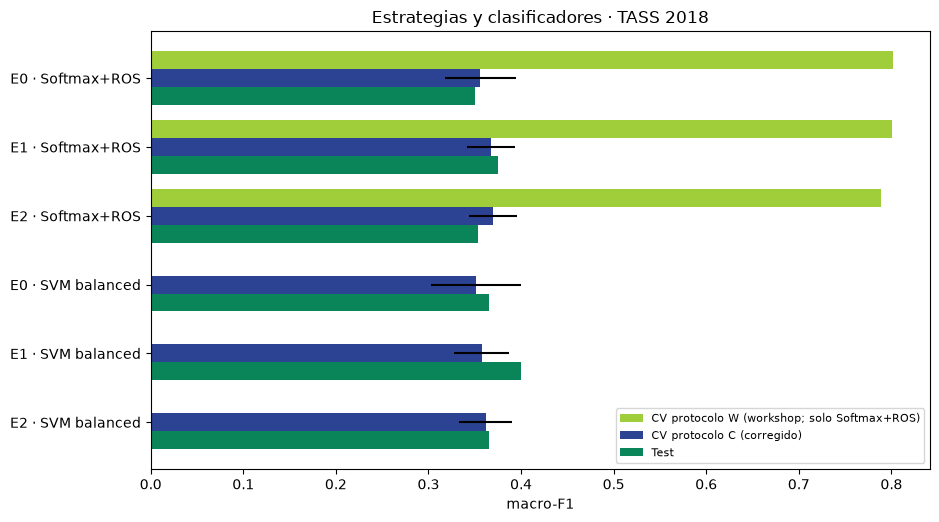

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 0.62 * len(summary) + 1.6))
y = np.arange(len(summary)); h = 0.26
ax.barh(y - h, summary["CV macro-F1 · protocolo W"], h, label="CV protocolo W (workshop; solo Softmax+ROS)", color="#A0CE3A")
ax.barh(y,     summary["CV macro-F1 · protocolo C"], h, xerr=summary["± std (C)"], label="CV protocolo C (corregido)", color="#2C4293")
ax.barh(y + h, summary["Test macro-F1"], h, label="Test", color="#098559")
ax.set_yticks(y); ax.set_yticklabels(summary.index); ax.invert_yaxis()
ax.set_xlabel("macro-F1"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("Estrategias y clasificadores · TASS 2018")
plt.tight_layout(); plt.show()

**Cómo leer la tabla.** *Fuga (W − C)* es cuánto se infla la métrica del workshop por evaluar con duplicados (solo aplica a Softmax+ROS). *Test macro-F1* es la referencia final: si el protocolo C se acerca más a *test* que el W, el protocolo corregido es el más fiable. Para comparar **ROS frente a `class_weight`**, usa las columnas del protocolo C y de *test*, que miden ambos con el mismo criterio.

## 7. Análisis

### 7.1 ¿Dónde ayudan los rasgos léxicos? F1 por clase (test)

In [10]:
per_class = pd.DataFrame({n: f1_score(y_test, preds[n], average=None, labels=range(len(le.classes_)), zero_division=0)
                          for n in EXPERIMENTS}, index=le.classes_).round(3)
for m in MODELS:
    per_class[f"Δ E2−E1 ({m})"] = (per_class[exp_name("E2", m)] - per_class[exp_name("E1", m)]).round(3)
per_class

,E0 · Softmax+ROS,E1 · Softmax+ROS,E2 · Softmax+ROS,E0 · SVM balanced,E1 · SVM balanced,E2 · SVM balanced,Δ E2−E1 (Softmax+ROS),Δ E2−E1 (SVM balanced)
N,0.662,0.647,0.612,0.653,0.657,0.635,-0.035,-0.022
NEU,0.110,0.147,0.137,0.147,0.188,0.155,-0.010,-0.033
NONE,0.077,0.182,0.150,0.119,0.206,0.154,-0.032,-0.052
P,0.554,0.526,0.514,0.544,0.547,0.516,-0.012,-0.031


### 7.2 ¿La diferencia es real o ruido?

Bootstrap pareado sobre *test*: se remuestrean los mismos tweets para ambos modelos y se calcula la diferencia de macro-F1. Si el intervalo de 95 % incluye 0, la diferencia no es demostrable con este tamaño de *test*. Se comparan las estrategias dentro de cada clasificador y, con la misma representación, Softmax+ROS frente a SVM balanced.

In [ ]:
def paired_bootstrap(y_true, p_a, p_b, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx, diffs = np.arange(len(y_true)), []
    for _ in range(n):
        s = rng.choice(idx, len(idx), replace=True)
        diffs.append(f1_score(y_true[s], p_b[s], average="macro") - f1_score(y_true[s], p_a[s], average="macro"))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return float(np.mean(diffs)), float(lo), float(hi)

pairs = []
for m in MODELS:
    pairs += [(exp_name("E0", m), exp_name("E1", m)), (exp_name("E1", m), exp_name("E2", m)), (exp_name("E0", m), exp_name("E2", m))]
pairs += [(exp_name(s, MODELS[0]), exp_name(s, MODELS[1])) for s in ("E0", "E1", "E2")]
rows = []
for a, b in pairs:
    d, lo, hi = paired_bootstrap(y_test, preds[a], preds[b])
    rows.append({"A": a, "B": b, "Δ macro-F1 (B−A)": round(d, 4), "IC95% inf": round(lo, 4),
                 "IC95% sup": round(hi, 4), "IC excluye 0": bool(lo > 0 or hi < 0)})
pd.DataFrame(rows)

### 7.3 Qué aprendió cada modelo de los rasgos léxicos

Coeficientes de E2 para los rasgos estandarizados (comparables entre sí dentro de un modelo; no entre Softmax y SVM, que tienen escalas distintas). Un coeficiente alto en una clase empuja la predicción hacia ella **manteniendo constante el resto**; con BoW en el mismo modelo, el efecto de cada rasgo léxico es condicional a las palabras presentes.

In [ ]:
for m in MODELS:
    clf = models[exp_name("E2", m)].named_steps["clf"]
    coef = pd.DataFrame(clf.coef_[:, -len(FEATURE_NAMES):], index=le.classes_, columns=FEATURE_NAMES).T
    coef["|max|"] = coef.abs().max(axis=1)
    print(f"E2 · {m}")
    display(coef.sort_values("|max|", ascending=False).head(10).drop(columns="|max|").round(3))

In [ ]:
best = summary["CV macro-F1 · protocolo C"].idxmax()        # se elige con validación cruzada, no con test
print("Mejor según CV (protocolo C):", best, "\n")
print(f"Tweets en test: {len(y_test):,}\n")
print(classification_report(y_test, preds[best], target_names=le.classes_, zero_division=0, digits=3))

# Soporte por clase e incertidumbre del F1 (bootstrap sobre test)
def f1_ci_por_clase(y_true, y_pred, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx, f = np.arange(len(y_true)), []
    for _ in range(n):
        s = rng.choice(idx, len(idx), replace=True)
        f.append(f1_score(y_true[s], y_pred[s], average=None, labels=range(len(le.classes_)), zero_division=0))
    f = np.array(f)
    return np.percentile(f, 2.5, axis=0), np.percentile(f, 97.5, axis=0)

lo, hi = f1_ci_por_clase(y_test, preds[best])
sup = np.bincount(y_test, minlength=len(le.classes_))
tabla_soporte = pd.DataFrame({
    "support": sup,
    "% del test": (100 * sup / sup.sum()).round(1),
    "F1": f1_score(y_test, preds[best], average=None, labels=range(len(le.classes_)), zero_division=0).round(3),
    "IC95% F1 inf": lo.round(3),
    "IC95% F1 sup": hi.round(3),
    "± máx. en recall (peor caso)": (1.96 * np.sqrt(0.25 / np.maximum(sup, 1))).round(3),
}, index=le.classes_)
tabla_soporte["soporte < 100"] = tabla_soporte["support"] < 100
display(tabla_soporte)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay.from_predictions(y_test, preds[best], display_labels=le.classes_, ax=ax, cmap="Blues", colorbar=False)
ax.set_title(best, fontsize=9); plt.tight_layout(); plt.show()

**Cómo leer el soporte (`support`).** Es el número de tweets *reales* de cada clase en *test*; no depende del modelo. Con pocos ejemplos, el F1 de esa clase es inestable: en el peor caso (proporción 0.5), con 62 tweets la incertidumbre del recall es de ±12 puntos (95 %), con 200 baja a ±7 y con 600 a ±4. Por eso la columna `IC95% F1` importa más que el F1 puntual, y una diferencia entre modelos en una clase de soporte bajo rara vez es demostrable.

**¿Qué partición es tu `test`?** Compara `len(y_test)` y los `support` con la Tabla 1 del *Overview of TASS 2018* (InterTASS ES):

| Partición | P | NEU | N | NONE | Total |
|---|---|---|---|---|---|
| Train | 317 | 133 | 416 | 138 | 1 008 |
| Dev | 156 | 69 | 219 | 62 | 506 |
| Test | 642 | 216 | 767 | 274 | 1 899 |

Si tus soportes coinciden con *Dev*, el archivo que llamas *test* es en realidad la partición de desarrollo (506 tweets), y la comparación con el 0.503 del *Overview* no es válida. Si tienes otras variedades (PE, CR) o una partición propia, los soportes serán distintos.

## 8. Interpretación y límites

**Preguntas que deben responder los números con datos reales de TASS:**

1. **E0 vs. E1:** ¿el preprocesamiento de `TextProcessing` cambia algo? Ojo: `transformer()` elimina acentos, así que *más* y *mas* (o *sí* y *si*) se confunden; puede ayudar (menos vocabulario) o dañar (ambigüedad).
2. **E1 vs. E2:** ¿aportan los rasgos léxicos? Si el intervalo bootstrap incluye 0, la respuesta es "no demostrable con este *test*".
3. **F1 por clase:** ¿el efecto se concentra en `NEU`/`NONE` (clases con menos señal léxica de polaridad) o en `P`/`N`?
4. **Fuga W − C:** ¿cuánto sobrestimaba el workshop original?
5. **Softmax+ROS vs. SVM balanced (mismas representaciones):** ¿el balanceo por pesos iguala o supera al sobremuestreo, y en qué clases? Mira el F1 de `NEU` y `NONE` en 7.1.

**Limitaciones.**

- Los léxicos de `lexical_features.py` son de categorías gramaticales y semánticas, no un léxico de sentimiento validado (por ejemplo, incluyen colores en las listas de adjetivos positivos y negativos). Es previsible que aporten poco a la polaridad.
- `weighted_position`/`weighted_normalized` son casi funciones de la longitud del mensaje, y `lexical_diversity` mide diversidad de caracteres, no de palabras.
- **Hiperparámetros sin ajustar:** Softmax usa `C=10` (el del workshop) y SVM `C=1` (valor por defecto). Una diferencia entre ambos puede deberse al `C` y no al método de balanceo; para separar los efectos hay que buscar `C` dentro de la validación cruzada (por ejemplo, `GridSearchCV` sobre el `Pipeline`).
- Una sola partición *train/test* y una sola semilla: el bootstrap cubre la variabilidad de la muestra de *test*, no la del reentrenamiento.
- **Referencia de comparación.** El workshop base cita ~0.65 de F1 para los mejores sistemas de TASS 2018; esa cifra no coincide con el *overview* oficial. En la Tabla 4 (InterTASS ES) el mejor sistema obtuvo macro-F1 = 0.503 y accuracy = 0.612 (*elirf-es-run-1*), y el segundo 0.499 (Martínez-Cámara et al., 2018, *Overview of TASS 2018*, CEUR-WS vol. 2172, pp. 13-27). Esa comparación solo es válida si tu *test* es el de InterTASS ES (1 899 tweets); con una partición propia de *train* no lo es.

**Extensiones.**

- Sustituir `CountVectorizer` por TF-IDF (ver `tass_lexical_tfidf_classification.ipynb`) y por *embeddings*; comparar contra un modelo preentrenado en español.
- Ablación por grupos de rasgos: solo etiquetas de Twitter, solo pronombres, solo adjetivos/adverbios.
- Sustituir los léxicos por un léxico de polaridad validado para español.

**Defensa oral.** Explica por qué el `StandardScaler` y el `CountVectorizer` deben ajustarse dentro de cada pliegue mientras que `LexicalVectorizer` puede calcularse antes de la validación cruzada.